# 🤖 Agentic RAG System — Google Colab (v2)

**Architecture overview:**
- 📄 **Document Ingestion** — upload your PDF from local disk
- 🔍 **VectorStore** — FAISS + HuggingFace embeddings (free, no OpenAI key)
- 🧠 **LLM** — Groq `llama-3.3-70b-versatile` via `langchain-groq`
- 🔗 **LangGraph** — `retriever → agent (retriever tool + Wikipedia tool)` → answer
- 🌐 **Tool-calling** — Groq-compatible `bind_tools` + manual `ToolMessage` loop
- 🖥️ **Streamlit app** — run in Colab via `pyngrok` tunnel

> **Before running:** add `GROQ_API_KEY` in *Colab Secrets* (🔑 left sidebar → Secrets).

## 1 · Install dependencies

In [27]:
# Pinned versions confirmed working with Groq + LangGraph on Colab
!pip install -q \
    langchain==0.3.27 \
    langchain-community==0.3.27 \
    langchain-groq \
    langchain-huggingface \
    langgraph==0.6.5 \
    faiss-cpu \
    pydantic \
    pypdf \
    wikipedia \
    sentence-transformers \
    beautifulsoup4 \
    requests \
    pyngrok \
    streamlit

import uuid  # keep in global scope — fixes langchain-core forward-ref NameError
print('✅ All packages installed successfully!')

✅ All packages installed successfully!


## 2 · Load Groq API Key from Colab Secrets

In [28]:
import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
print('✅ GROQ_API_KEY loaded!')

✅ GROQ_API_KEY loaded!


## 3 · Configuration  (`src/config/config.py`)

In [29]:
import os
from langchain_groq import ChatGroq

class Config:
    """Configuration for the Agentic RAG system."""
    LLM_MODEL       = 'llama-3.1-8b-instant'
    EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
    CHUNK_SIZE      = 500
    CHUNK_OVERLAP   = 50

    @classmethod
    def get_llm(cls):
        """Return a plain ChatGroq — tools bound separately per RAGNodes instance."""
        return ChatGroq(
            model=cls.LLM_MODEL,
            api_key=os.environ['GROQ_API_KEY'],
            temperature=0,
        )

print(f'✅ Config ready  |  LLM: {Config.LLM_MODEL}  |  Embeddings: {Config.EMBEDDING_MODEL}')

✅ Config ready  |  LLM: llama-3.1-8b-instant  |  Embeddings: all-MiniLM-L6-v2


## 4 · RAG State  (`src/state/rag_state.py`)

In [30]:
from typing import List
from pydantic import BaseModel, ConfigDict
from langchain_core.documents import Document

class RAGState(BaseModel):
    """Typed state object flowing through the LangGraph pipeline."""
    question      : str
    retrieved_docs: List[Document] = []
    answer        : str = ''
    model_config = ConfigDict(arbitrary_types_allowed=True)

print('✅ RAGState defined')

✅ RAGState defined


## 5 · Document Processor  (`src/document_ingestion/document_processor.py`)

In [31]:
from typing import List, Union
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

class DocumentProcessor:
    """Load documents from PDFs / URLs / TXT files and split into chunks."""

    def __init__(self, chunk_size: int = 500, chunk_overlap: int = 50):
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap
        )

    def load_from_pdf(self, file_path: Union[str, Path]) -> List[Document]:
        return PyPDFLoader(str(file_path)).load()

    def load_from_url(self, url: str) -> List[Document]:
        return WebBaseLoader(url).load()

    def load_from_txt(self, file_path: Union[str, Path]) -> List[Document]:
        return TextLoader(str(file_path), encoding='utf-8').load()

    def load_documents(self, sources: List[str]) -> List[Document]:
        docs: List[Document] = []
        for src in sources:
            src = src.strip()
            if src.startswith('http://') or src.startswith('https://'):
                print(f'  🌐 URL: {src}')
                docs.extend(self.load_from_url(src))
            else:
                path = Path(src)
                if path.suffix.lower() == '.pdf':
                    print(f'  📄 PDF: {path.name}')
                    docs.extend(self.load_from_pdf(path))
                elif path.suffix.lower() == '.txt':
                    print(f'  📝 TXT: {path.name}')
                    docs.extend(self.load_from_txt(path))
                else:
                    raise ValueError(f'Unsupported source: {src}')
        return docs

    def split_documents(self, documents: List[Document]) -> List[Document]:
        return self.splitter.split_documents(documents)

    def process(self, sources: List[str]) -> List[Document]:
        raw = self.load_documents(sources)
        chunks = self.split_documents(raw)
        print(f'  ✂️  {len(raw)} pages → {len(chunks)} chunks')
        return chunks

print('✅ DocumentProcessor defined')

✅ DocumentProcessor defined


## 6 · VectorStore  (`src/vectorstore/vectorstore.py`)

In [32]:
from typing import List
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

class VectorStore:
    """FAISS vector store with local HuggingFace embeddings."""

    def __init__(self, model_name: str = Config.EMBEDDING_MODEL):
        print(f'  🔄 Loading embedding model: {model_name} …')
        self.embedding   = HuggingFaceEmbeddings(model_name=model_name)
        self.vectorstore = None
        self.retriever   = None
        print('  ✅ Embedding model loaded')

    def create_vectorstore(self, documents: List[Document]):
        print(f'  🔍 Embedding {len(documents)} chunks …')
        self.vectorstore = FAISS.from_documents(documents, self.embedding)
        self.retriever   = self.vectorstore.as_retriever(search_kwargs={'k': 6})
        print('  ✅ FAISS index created')

    def get_retriever(self):
        if self.retriever is None:
            raise ValueError('Call create_vectorstore() first.')
        return self.retriever

    def retrieve(self, query: str) -> List[Document]:
        return self.get_retriever().invoke(query)

print('✅ VectorStore defined')

✅ VectorStore defined


## 7 · LangGraph Nodes  (`src/node/reactnode.py`)

**Groq-compatible tool-calling strategy** (no `create_react_agent`, no `AgentExecutor`):
1. Build `@tool`-decorated functions for document search and Wikipedia
2. Bind them to the LLM once with `llm.bind_tools(tools)`
3. In `generate_answer`, run a **manual loop**: call LLM → if `tool_calls` present → execute tools → append `ToolMessage` results → call LLM again
4. Stop when LLM returns a plain-text answer (no `tool_calls`) or `max_iterations` reached


In [33]:
# src/node/reactnode.py  (inlined for Colab)
from typing import List, Optional
from langchain_core.documents import Document
from langchain_core.messages import (
    HumanMessage, SystemMessage, ToolMessage, AIMessage
)
from langchain_core.tools import tool


# ── Tool factory ──────────────────────────────────────────────────────────────
# Defined via factory so the retriever closure is captured cleanly.
# Using @tool decorator (not Tool()) avoids the uuid NameError in
# LangGraph's ToolNode type-hint inspection.

def _make_tools(retriever):
    """Return [search_documents, search_wikipedia] tools bound to retriever."""

    @tool
    def search_documents(query: str) -> str:
        """Search the uploaded PDF document for relevant passages. Always call this first."""
        docs: List[Document] = retriever.invoke(query)
        if not docs:
            return 'No relevant passages found in the document.'
        parts = []
        for i, d in enumerate(docs[:6], start=1):
            meta = d.metadata if hasattr(d, 'metadata') else {}
            page = meta.get('page', '?')
            src  = meta.get('source', meta.get('file_path', f'chunk_{i}'))
            parts.append(f'[{i}] (source={src}, page={page})\n{d.page_content}')
        return '\n\n'.join(parts)

    @tool
    def search_wikipedia(query: str) -> str:
        """Search Wikipedia for general background knowledge when the document lacks the answer."""
        from langchain_community.utilities import WikipediaAPIWrapper
        wrapper = WikipediaAPIWrapper(
            top_k_results=2, lang='en', doc_content_chars_max=2000
        )
        try:
            return wrapper.run(query)
        except Exception as e:
            return f'Wikipedia search failed: {e}'

    return [search_documents, search_wikipedia]


# ── RAGNodes ──────────────────────────────────────────────────────────────────
class RAGNodes:
    """Contains node functions for the LangGraph RAG workflow."""

    def __init__(self, retriever, llm, max_iterations: int = 5):
        self.retriever      = retriever
        self.llm            = llm
        self.max_iterations = max_iterations
        # Build tools and bind to LLM once at init time
        self._tools         = _make_tools(retriever)
        self._tool_map      = {t.name: t for t in self._tools}
        self._llm_with_tools = llm.bind_tools(self._tools)

    # ── Node 1: retrieve_docs ─────────────────────────────────────────────────
    def retrieve_docs(self, state: RAGState) -> RAGState:
        """Pre-fetch top-k docs so state.retrieved_docs is always populated."""
        docs = self.retriever.invoke(state.question)
        return RAGState(question=state.question, retrieved_docs=docs)

    # ── Node 2: generate_answer ───────────────────────────────────────────────
    def generate_answer(self, state: RAGState) -> RAGState:
        """
        Groq-compatible agentic tool loop.
        Uses bind_tools + manual ToolMessage loop instead of create_react_agent,
        which avoids the Groq BadRequestError (tool_use_failed).
        """
        system = SystemMessage(content=(
            'You are a helpful RAG assistant. '
            'Use search_documents first to find information from the uploaded PDF. '
            'Use search_wikipedia only if the document does not contain enough information. '
            'After gathering information, provide a clear, concise final answer.'
        ))
        messages = [system, HumanMessage(content=state.question)]
        response: Optional[AIMessage] = None

        for _ in range(self.max_iterations):
            response = self._llm_with_tools.invoke(messages)
            messages.append(response)

            # No tool calls → LLM has produced a final answer
            if not getattr(response, 'tool_calls', None):
                break

            # Execute each requested tool and feed results back as ToolMessages
            for tc in response.tool_calls:
                name   = tc['name']
                args   = tc['args']
                tid    = tc['id']
                if name in self._tool_map:
                    try:
                        result = self._tool_map[name].invoke(args)
                    except Exception as e:
                        result = f'Tool error: {e}'
                else:
                    result = f'Unknown tool: {name}'
                messages.append(ToolMessage(content=str(result), tool_call_id=tid))
        else:
            # Reached max_iterations — force a final answer
            response = self._llm_with_tools.invoke(
                messages + [HumanMessage(content='Please provide your final answer now.')]
            )

        answer = response.content if response else 'Could not generate an answer.'
        return RAGState(
            question=state.question,
            retrieved_docs=state.retrieved_docs,
            answer=answer,
        )

print('✅ RAGNodes defined  (src/node/reactnode.py)')
print('   Tools: search_documents + search_wikipedia')
print('   Loop : bind_tools + manual ToolMessage loop (Groq-safe)')

✅ RAGNodes defined  (src/node/reactnode.py)
   Tools: search_documents + search_wikipedia
   Loop : bind_tools + manual ToolMessage loop (Groq-safe)


## 8 · Graph Builder  (`src/graph_builder/graph_builder.py`)

In [34]:
from langgraph.graph import StateGraph, END

class GraphBuilder:
    """Assembles and compiles the LangGraph RAG workflow."""

    def __init__(self, retriever, llm):
        self.nodes = RAGNodes(retriever, llm)
        self.graph = None

    def build(self):
        builder = StateGraph(RAGState)
        builder.add_node('retriever', self.nodes.retrieve_docs)
        builder.add_node('responder', self.nodes.generate_answer)
        builder.set_entry_point('retriever')
        builder.add_edge('retriever', 'responder')
        builder.add_edge('responder', END)
        self.graph = builder.compile()
        print('✅ LangGraph compiled  →  retriever ➜ responder ➜ END')
        return self.graph

    def run(self, question: str) -> dict:
        if self.graph is None:
            self.build()
        return self.graph.invoke(RAGState(question=question))

print('✅ GraphBuilder defined')

✅ GraphBuilder defined


## 9 · Upload your PDF from local disk

Run the cell — a file picker will appear. Select your PDF and wait for the upload.

In [35]:
from google.colab import files
import os

print('📂 Please select your PDF file …')
uploaded     = files.upload()
pdf_filename = list(uploaded.keys())[0]
PDF_PATH     = os.path.abspath(pdf_filename)

print(f'\n✅ Uploaded : {pdf_filename}  ({len(uploaded[pdf_filename]):,} bytes)')
print(f'   Saved to : {PDF_PATH}')

📂 Please select your PDF file …


Saving attention.pdf to attention (1).pdf

✅ Uploaded : attention (1).pdf  (2,215,244 bytes)
   Saved to : /content/attention (1).pdf


## 10 · Initialise the full RAG pipeline

In [36]:
import time

print('🚀 Initialising Agentic RAG System …\n')

llm = Config.get_llm()
print(f'✅ LLM ready: {Config.LLM_MODEL} (Groq)\n')

print('📄 Loading & chunking PDF …')
doc_processor = DocumentProcessor(
    chunk_size=Config.CHUNK_SIZE, chunk_overlap=Config.CHUNK_OVERLAP
)
documents = doc_processor.process([PDF_PATH])
print(f'   Total chunks: {len(documents)}\n')

print('🔍 Building FAISS vector store …')
vector_store = VectorStore()
vector_store.create_vectorstore(documents)
print()

print('🔗 Building LangGraph …')
graph_builder = GraphBuilder(
    retriever=vector_store.get_retriever(),
    llm=llm,
)
graph_builder.build()
print('\n🎉 System ready — start asking questions!')

🚀 Initialising Agentic RAG System …

✅ LLM ready: llama-3.1-8b-instant (Groq)

📄 Loading & chunking PDF …
  📄 PDF: attention (1).pdf
  ✂️  15 pages → 93 chunks
   Total chunks: 93

🔍 Building FAISS vector store …
  🔄 Loading embedding model: all-MiniLM-L6-v2 …


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  ✅ Embedding model loaded
  🔍 Embedding 93 chunks …
  ✅ FAISS index created

🔗 Building LangGraph …
✅ LangGraph compiled  →  retriever ➜ responder ➜ END

🎉 System ready — start asking questions!


## 11 · Ask a single question

In [37]:
import time

question = 'What is attention mechanism?'  # ← edit this

print(f'❓ Question: {question}\n')
t0      = time.time()
result  = graph_builder.run(question)
elapsed = time.time() - t0

print(f'\n💡 Answer:\n{result["answer"]}')
print(f'\n⏱️  {elapsed:.2f}s  |  {len(result["retrieved_docs"])} docs retrieved')

❓ Question: What is attention mechanism?


💡 Answer:
The attention mechanism is a method in machine learning that determines the importance of each component in a sequence relative to the other components in that sequence. In natural language processing, importance is represented by "soft" weights assigned to each word in a sentence. The attention mechanism was developed to address the weaknesses of using information from the hidden layers of recurrent neural networks, allowing a token equal access to any part of a sentence directly, rather than only through the previous state. It has become a crucial component of many artificial intelligence models, including large language models, and is widely used in applications such as machine translation and text summarization.

⏱️  1.85s  |  6 docs retrieved


## 12 · Inspect retrieved source passages

In [38]:
for i, doc in enumerate(result['retrieved_docs'], start=1):
    meta   = doc.metadata
    source = meta.get('source', meta.get('file_path', 'unknown'))
    page   = meta.get('page', '?')
    print(f'--- Doc {i} | source: {source} | page: {page} ---')
    print(doc.page_content[:400])
    print()

--- Doc 1 | source: /content/attention (1).pdf | page: 12 ---
.
<EOS>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
Figure 3: An example of the attention mechanism following long-distance dependencies in the
encoder self-attention in layer 5 of 6. Many of the attention heads attend to a distant dependency of
the verb ‘making’, completing the phrase ‘making...more difficult’. Attentions here shown only for
the word ‘making’. Different colors represent different heads. 

--- Doc 2 | source: /content/attention (1).pdf | page: 14 ---
but
its
application
should
be
just
-
this
is
what
we
are
missing
,
in
my
opinion
.
<EOS>
<pad>
Figure 5: Many of the attention heads exhibit behaviour that seems related to the structure of the
sentence. We give two such examples above, from two different heads from the encoder self-attention
at layer 5 of 6. The heads clearly learned to perform different tasks.
15

--- Doc 3 | source: /content/attention (1).pdf | page: 6 ---
from our models and present and discuss exam

## 13 · Interactive Q&A loop

Type questions one at a time. Enter `quit` to stop.

In [39]:
import time

print('💬 Interactive Mode — type "quit" to stop\n')
print('─' * 60)

while True:
    try:
        q = input('\nYour question: ').strip()
    except EOFError:
        break
    if not q:
        continue
    if q.lower() in ('quit', 'exit', 'q'):
        print('👋 Goodbye!')
        break
    t0     = time.time()
    result = graph_builder.run(q)
    print(f'\n💡 Answer:\n{result["answer"]}')
    print(f'\n⏱️  {time.time()-t0:.2f}s  |  {len(result["retrieved_docs"])} docs retrieved')
    print('─' * 60)

💬 Interactive Mode — type "quit" to stop

────────────────────────────────────────────────────────────

Your question: what is attention?

💡 Answer:
Attention is the concentration of awareness directed at some duty while mostly excluding others. It is a complex phenomenon that involves the allocation of limited cognitive processing resources to a subset of information, thoughts, or tasks. Attention is not a unitary phenomenon but an umbrella term for multiple related processes, including selective attention, sustained attention, divided attention, and orienting. These processes are supported by distributed neural networks in frontal, parietal, and subcortical regions and are closely linked to working memory, executive functions, and consciousness.

⏱️  1.87s  |  6 docs retrieved
────────────────────────────────────────────────────────────

Your question: quit
👋 Goodbye!


## 14 · Batch questions (optional)

In [40]:
import time

BATCH_QUESTIONS = [
    'What is the main contribution of this paper?',
    'What methods or techniques are described?',
    'What are the key findings or results?',
]

print('=' * 60)
print('📝 Batch Q&A')
print('=' * 60)

for bq in BATCH_QUESTIONS:
    print(f'\n❓ {bq}')
    t0  = time.time()
    res = graph_builder.run(bq)
    print(f'💡 {res["answer"]}')
    print(f'   ⏱️  {time.time()-t0:.2f}s')
    print('-' * 60)

📝 Batch Q&A

❓ What is the main contribution of this paper?
💡 The main contribution of the paper "Attention Is All You Need" is the introduction of the Transformer model, a novel neural network architecture that uses self-attention mechanisms to process input sequences without relying on recurrent neural networks (RNNs) or convolutional neural networks (CNNs). The paper shows that the Transformer model can achieve state-of-the-art results on several machine translation tasks, outperforming previous models that used RNNs or CNNs. The Transformer model's ability to process input sequences in parallel, rather than sequentially, makes it more efficient and scalable than previous models.
   ⏱️  2.19s
------------------------------------------------------------

❓ What methods or techniques are described?
💡 Based on the information gathered from the uploaded PDF document, the methods or techniques described are:

1. Attention mechanism in the encoder self-attention in layer 5 of 6.
2. Traini

---
## 15 · Streamlit App  (`streamlit_app.py`)

The cells below write the Streamlit app to disk and launch it with `pyngrok`.  
A public URL will appear — open it to use the full chat UI.

> The Streamlit app is self-contained: it re-initialises its own RAG pipeline  
> internally (same architecture — PDF upload via sidebar, Groq LLM, FAISS, LangGraph).

### 15a · Write `streamlit_app.py` to disk

In [52]:
st_source = [
    'import os, time\n',
    'import streamlit as st\n',
    'from typing import List\n',
    'from pydantic import BaseModel, ConfigDict\n',
    'from langchain_groq import ChatGroq\n',
    'from langchain_community.document_loaders import PyPDFLoader\n',
    'from langchain_text_splitters import RecursiveCharacterTextSplitter\n',
    'from langchain_community.vectorstores import FAISS\n',
    'from langchain_huggingface import HuggingFaceEmbeddings\n',
    'from langchain_core.documents import Document\n',
    'from langchain_core.messages import HumanMessage, SystemMessage\n',
    '\n',
    '# ── constants ────────────────────────────────────────────────────────────────\n',
    "GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')\n",
    "LLM_MODEL    = 'llama-3.1-8b-instant'\n",
    "EMBED_MODEL  = 'all-MiniLM-L6-v2'\n",
    '\n',
    '# ── page config ───────────────────────────────────────────────────────────────\n',
    "st.set_page_config(page_title='Agentic RAG', page_icon='🤖', layout='centered')\n",
    "st.title('🤖 Agentic RAG — PDF Q&A')\n",
    "st.caption('Powered by Groq · FAISS · HuggingFace Embeddings')\n",
    '\n',
    '# ── cached pipeline init ──────────────────────────────────────────────────────\n',
    '@st.cache_resource\n',
    'def init_pipeline(pdf_bytes, filename):\n',
    "    tmp = f'/tmp/{filename}'\n",
    "    with open(tmp, 'wb') as f:\n",
    '        f.write(pdf_bytes)\n',
    '    pages  = PyPDFLoader(tmp).load()\n',
    '    chunks = RecursiveCharacterTextSplitter(\n',
    '        chunk_size=500, chunk_overlap=50\n',
    '    ).split_documents(pages)\n',
    '    embed = HuggingFaceEmbeddings(model_name=EMBED_MODEL)\n',
    '    vs    = FAISS.from_documents(chunks, embed)\n',
    "    ret   = vs.as_retriever(search_kwargs={'k': 6})\n",
    '    llm   = ChatGroq(model=LLM_MODEL, api_key=GROQ_API_KEY, temperature=0)\n',
    '    return llm, ret, len(chunks)\n',
    '\n',
    '# ── RAG answer (no tool-calling API — retriever called directly) ──────────────\n',
    'def run_rag(question: str, llm, retriever) -> str:\n',
    '    # Step 1: retrieve relevant chunks directly\n',
    '    docs = retriever.invoke(question)\n',
    '    if docs:\n',
    '        context_parts = []\n',
    '        for i, d in enumerate(docs, 1):\n',
    "            page = d.metadata.get('page', '?') if hasattr(d, 'metadata') else '?'\n",
    "            context_parts.append(f'[{i}] (page={page})\\n{d.page_content}')\n",
    "        context = '\\n\\n'.join(context_parts)\n",
    '    else:\n',
    "        context = 'No relevant passages found in the document.'\n",
    '    # Step 2: send context + question to LLM — plain chat, no tools\n',
    '    messages = [\n',
    '        SystemMessage(content=(\n',
    "            'You are a helpful RAG assistant. '\n",
    "            'Answer the question using ONLY the context passages provided below. '\n",
    "            'If the context does not contain the answer, say so clearly.'\n",
    '        )),\n',
    "        HumanMessage(content=f'Context:\\n{context}\\n\\nQuestion: {question}'),\n",
    '    ]\n',
    '    response = llm.invoke(messages)\n',
    '    return response.content\n',
    '\n',
    '# ── sidebar ───────────────────────────────────────────────────────────────────\n',
    'with st.sidebar:\n',
    "    st.header('📄 Upload PDF')\n",
    "    uploaded_file = st.file_uploader('Choose a PDF', type='pdf')\n",
    "    st.markdown('---')\n",
    "    st.caption(f'Model: {LLM_MODEL}')\n",
    "    st.caption(f'Embeddings: {EMBED_MODEL}')\n",
    '\n',
    'if not uploaded_file:\n',
    "    st.info('👈 Upload a PDF from the sidebar to get started.')\n",
    '    st.stop()\n',
    '\n',
    "with st.spinner('🔄 Initialising pipeline (first run ~30s) …'):\n",
    '    llm, retriever, n_chunks = init_pipeline(\n',
    '        uploaded_file.read(), uploaded_file.name\n',
    '    )\n',
    "st.success(f'✅ Ready — {n_chunks} chunks indexed from **{uploaded_file.name}**')\n",
    '\n',
    '# ── chat history ──────────────────────────────────────────────────────────────\n',
    "if 'history' not in st.session_state:\n",
    '    st.session_state.history = []\n',
    '\n',
    'for turn in st.session_state.history:\n',
    "    with st.chat_message('user'):\n",
    "        st.write(turn['q'])\n",
    "    with st.chat_message('assistant'):\n",
    "        st.write(turn['a'])\n",
    '        st.caption(f"⏱️ {turn[\'t\']:.2f}s")\n',
    '\n',
    '# ── chat input ────────────────────────────────────────────────────────────────\n',
    "question = st.chat_input('Ask a question about your PDF …')\n",
    'if question:\n',
    "    with st.chat_message('user'):\n",
    '        st.write(question)\n',
    "    with st.chat_message('assistant'):\n",
    "        with st.spinner('🤔 Thinking …'):\n",
    '            t0      = time.time()\n',
    '            answer  = run_rag(question, llm, retriever)\n',
    '            elapsed = time.time() - t0\n',
    '        st.write(answer)\n',
    "        st.caption(f'⏱️ {elapsed:.2f}s')\n",
    "    st.session_state.history.append({'q': question, 'a': answer, 't': elapsed})\n",
]
with open('streamlit_app.py', 'w') as f:
    f.writelines(st_source)
print('✅ streamlit_app.py written (%d lines)' % len(st_source))

✅ streamlit_app.py written (104 lines)


### 15b · Launch Streamlit with pyngrok

A public URL will appear below — open it in a new browser tab.

In [50]:
import subprocess, time, os
from pyngrok import ngrok

# Kill any previous instance
os.system('pkill -f streamlit 2>/dev/null; sleep 1')

# Optional: set ngrok auth token to remove session limits
from google.colab import userdata
ngrok.set_auth_token(userdata.get('NGROK_AUTHTOKEN'))

# Launch Streamlit in background
proc = subprocess.Popen(
    ['streamlit', 'run', 'streamlit_app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
time.sleep(4)  # wait for Streamlit to start

public_url = ngrok.connect(8501)
print('\n' + '=' * 60)
print('🚀 Streamlit is running!')
print(f'🌐 Open in browser: {public_url}')
print('=' * 60)
print('\n   Upload your PDF in the sidebar and start chatting.')
print('   Run the cell below to stop the server.')


🚀 Streamlit is running!
🌐 Open in browser: NgrokTunnel: "https://nuggety-zeke-buckishly.ngrok-free.dev" -> "http://localhost:8501"

   Upload your PDF in the sidebar and start chatting.
   Run the cell below to stop the server.


### 15c · Stop Streamlit server

In [53]:
from pyngrok import ngrok
import os

ngrok.kill()
os.system('pkill -f streamlit 2>/dev/null')
print('✅ Streamlit server stopped')

✅ Streamlit server stopped


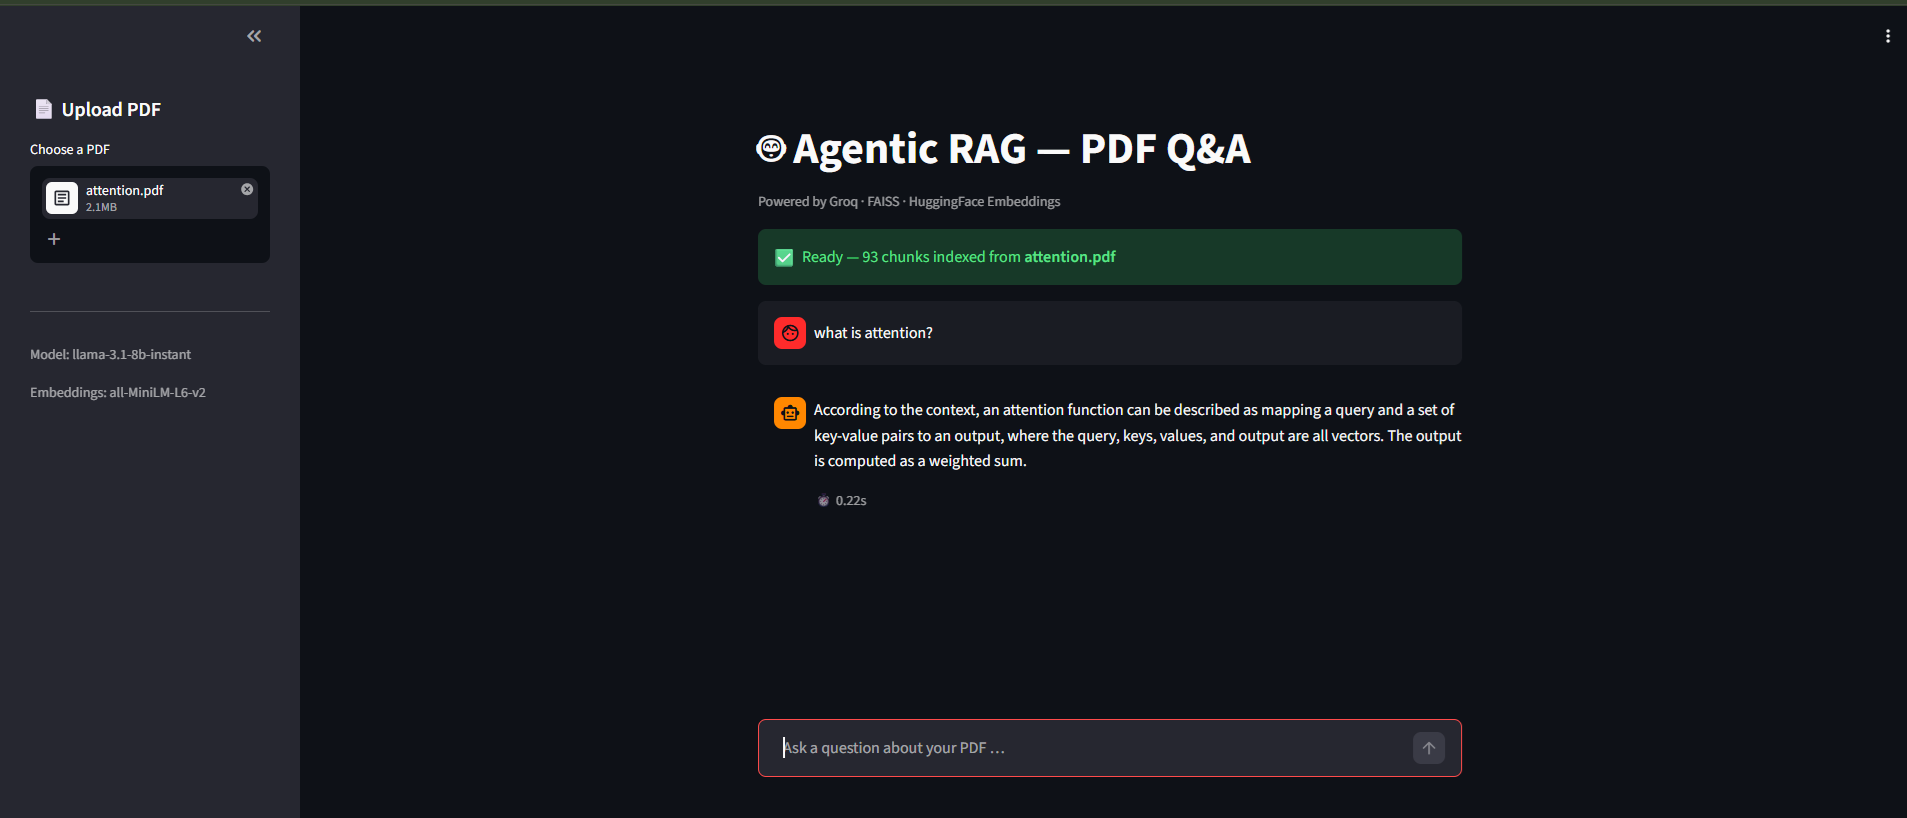

In [54]:
from IPython.display import Image, display
display(Image(filename='/content/app.png'))